## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 Section 002 (Spring 2026)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

**Sulfuric Acid Production (Simplified Contact Process)**

In the Contact Process, sulfur dioxide is converted into sulfuric acid through a sequence of chemical reactions. A simplified kinetic model treats the process as a chain of consecutive first‑order reactions:

$\mathrm{SO_2}$  $\longrightarrow$  $\mathrm{SO_3}$  $\longrightarrow$  $\mathrm{H_2}\mathrm{SO_4}\mathrm{SO_2}$ 

Assume the reactor is well‑mixed and that temperature and pressure are constant.

We will use the following variables:

* **x:** concentration of sulfur dioxide ($\mathrm{SO_2}$  ) in mol/L
* **y:** concentration of sulfur trioxide ($\mathrm{SO_3}$) in mol/L
* **z:** concentration of sulfuric acid ($\mathrm{H_2}\mathrm{SO_4}\mathrm{SO_2}$) in mol/L

All concentrations depend on time t (minutes).

Now for the differental equations!

The system is modeled by:
\begin{aligned}
\frac{dx}{dt} &= -\mathrm{k_{one}} x \\
\frac{dy}{dt} &= \mathrm{k_{one}} x - \mathrm{k_{two}} y \\
\frac{dz}{dt} &= \mathrm{k_{two}} y \\
\end{aligned}

* $k_{one}$ = 0.4 $\text{min}^{-1}$ is the rate constant for $\mathrm{SO_2}$  $\longrightarrow$  $\mathrm{SO_3}$ 
* $k_{two}$ = 0.2 $\text{min}^{-1}$ is the rate constant for  $\mathrm{SO_3}$  $\longrightarrow$  $\mathrm{H_2}\mathrm{SO_4}\mathrm{SO_2}$ 


Finally, we have initial conditions:

At t=0:
* x(0) = 1.0
* y(0) = 0
* z(0) = 0

Evolve the model for 20 minutes using a timestep of $\Delta t = 0.1$ minutes.

**Code you need to write to solve this problem**:
* A function that takes in a set of time values as well as the current values for $x$, $y$, and $z$ and **returns** the derivatives for each variable, $\frac{dx}{dt}$, $\frac{dy}{dt}$, and $\frac{dz}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* A set of variables for storing your initial conditions, $x_0$, $y_0$, and $z_0$, set to the correct initial values.
* A variable that stores all the times for which you want to solve the system of ODEs. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* Code that unpacks the solution so that you can plot it.

**Note**: you will not need the "`args`" argument for `solve_ivp` for this case because any model parameters that might be needed for this system are provided directly as numbers in the set of  ODEs include above.

In [ ]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [22]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals):
    kone = 0.4
    ktwo = 0.1
    x, y, z = vals
    dxdt = -kone*x
    dydt = kone*x - ktwo*y
    dzdt = ktwo*y
    return dxdt, dydt, dzdt

# Solve the system
x0 = 1.0
y0 = 0
z0 = 0
ICs = [x0, y0, z0]
t = np.arange(0, 20, 0.1)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t)
x = sol.y[0,:]
y = sol.y[1,:]
z = sol.y[2,:]
print(x)

[1.00000000e+00 9.60789436e-01 9.23116345e-01 8.86920390e-01
 8.52142768e-01 8.18728344e-01 7.86624401e-01 7.55779935e-01
 7.26145654e-01 6.97673975e-01 6.70319028e-01 6.44036654e-01
 6.18784404e-01 5.94521033e-01 5.71204978e-01 5.48800597e-01
 5.27273985e-01 5.06592130e-01 4.86722908e-01 4.67635083e-01
 4.49298311e-01 4.31683137e-01 4.14760995e-01 3.98504209e-01
 3.82885991e-01 3.67880445e-01 3.53462564e-01 3.39608228e-01
 3.26294209e-01 3.13496785e-01 3.01194904e-01 2.89371479e-01
 2.78009775e-01 2.67093393e-01 2.56606269e-01 2.46532669e-01
 2.36857197e-01 2.27564789e-01 2.18640715e-01 2.10070579e-01
 2.01840319e-01 1.93936207e-01 1.86344849e-01 1.79053184e-01
 1.72048488e-01 1.65318366e-01 1.58850761e-01 1.52633949e-01
 1.46656538e-01 1.40907541e-01 1.35378355e-01 1.30062026e-01
 1.24951578e-01 1.20040144e-01 1.15320964e-01 1.10787388e-01
 1.06432876e-01 1.02250993e-01 9.82354167e-02 9.43799309e-02
 9.06784290e-02 8.71249131e-02 8.37134939e-02 8.04383907e-02
 7.72939317e-02 7.427455

&#9989;&nbsp; **Question 1.2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, humus, dead trees, and living trees as a function time. Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

If all goes well, you should end up with something that looks like this:

![Reaction Model](Quiz4_Q2.png)

In [3]:
# put your code here

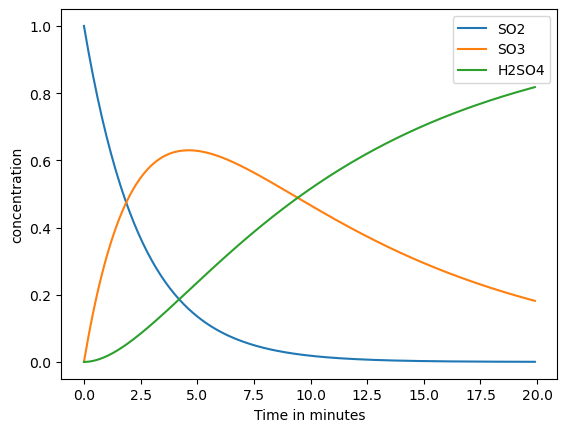

In [24]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

# In minutes
plt.figure(1)
plt.plot(t,x,label="SO2")
plt.plot(t,y,label="SO3")
plt.plot(t,z,label="H2SO4")
plt.xlabel("Time in minutes")
plt.ylabel("concentration")
plt.legend()
plt.savefig("Quiz4_Q2.png")

#### &#9989;&nbsp; **Question 1.3 Documenting Your Solution Pathway (10 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Part 1 you answered with prior knowledge, and also indicate which portions of Part 1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (2 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (8 points)
3. Does your solution work? (2 point)
4. **If your solution works**, how do you know it works?  Include any calculations you made, tests you ran, etc. **If your solution DOES NOT work**, how do you know it does not work?  What approaches would you use to verify a correct solution? (8 points)

### &#9998; PUT YOUR ANSWER HERE!

### ANSWER ###

RUBRIC
* 1 point indicating which portions were solved with prior knowledge and which portions were solved with outside resources
* 2 points documenting external sources usage
* 2 points indicating what prior knowledge helped
* 1 point answering if code worked
* 4 points for any well-thought out answer about how they know it does or does not work.  2 points for a superficial answer.  0 points for a blank or an answer that does not match the results

## Part 2: Data Visualization (50 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 30 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. 

&#9989;&nbsp; **Question 2 (20 points total)**: Grade the visualization using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (4 Points)** 
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

### Visualizations to Choose From


#### **Visualization 1**
![Georgia COVID Data](GA_COVID.jpg)


#### **Visualization 2**
![Higher Ed Data](Higher_Ed.jpg)

#### **Visualization 3**
![Acceptable Cats](acceptable_cats_chatgpt.png)

#### **Visualization 4**
![Injuries](injuries.png)

#### **Visualization 5**
![Life Expectancy](life_expectancy.png)

#### **Visualization 6**
![Retirement Costs](retirement.jpg)

#### **Visualization 7**
![Rare Earth Metals](VisualCapitalist_RareEarthMetals.jpg)

#### **Visualization 8**
![Turkeys](VisualCapitalist_Turkeys.jpg)

### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations and add your favorite bad visualizations!



**QUESTION 1 RESPONSES HERE**

**QUESTION 2 RESPONSES HERE**